# Performance Benchmarks

This notebook times representative Python-extension calls for the Rust `spafe` crate. The goal is to compare relative costs across feature families and signal durations, not to produce machine-independent absolute numbers.

> Run from an environment where the local extension is installed:
>
> ```bash
> python -m pip install maturin notebook matplotlib
> maturin develop
> jupyter notebook notebooks
> ```
>
> For portable SIMD experiments, rebuild the extension with nightly Rust and the SIMD feature enabled, then rerun this notebook:
>
> ```bash
> maturin develop --features python-extension,portable-simd -- --config build.rustflags=["-Ctarget-cpu=native"]
> ```

In [1]:
import math
import statistics
import time
from collections.abc import Callable

import matplotlib.pyplot as plt
import spafe

In [2]:
def sine_wave(seconds: float, fs: int = 16_000, frequency: float = 440.0) -> list[float]:
    return [
        math.sin(2.0 * math.pi * frequency * idx / fs)
        for idx in range(int(seconds * fs))
    ]


def benchmark(label: str, func: Callable[[], object], repeats: int = 5) -> dict[str, float | str]:
    # Warm up planner caches and one-time allocations where possible.
    func()
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        func()
        timings.append(time.perf_counter() - start)
    return {
        "label": label,
        "min_ms": min(timings) * 1000.0,
        "median_ms": statistics.median(timings) * 1000.0,
        "max_ms": max(timings) * 1000.0,
    }


def print_table(rows: list[dict[str, float | str]]) -> None:
    print(f"{'case':28s} {'min ms':>10s} {'median ms':>10s} {'max ms':>10s}")
    print("-" * 62)
    for row in rows:
        print(
            f"{row['label']:28s} "
            f"{row['min_ms']:10.3f} "
            f"{row['median_ms']:10.3f} "
            f"{row['max_ms']:10.3f}"
        )

## Feature Family Comparison

This section uses the same one-second signal and options for several feature extractors. It shows which feature families are cheap wrappers around a shared spectrogram path and which ones do more work.

In [3]:
fs = 16_000
signal = sine_wave(1.0, fs=fs)
opts = spafe.FeatureOptions(fs=fs, nfft=256, nfilts=24, num_ceps=13, win_hop=0.02)
cqcc_opts = spafe.CqccOptions(number_of_octaves=5, number_of_bins_per_octave=12)

feature_cases = [
    ("mfcc", lambda: spafe.mfcc(signal, opts)),
    ("lfcc", lambda: spafe.lfcc(signal, opts)),
    ("bfcc", lambda: spafe.bfcc(signal, opts)),
    ("gfcc", lambda: spafe.gfcc(signal, opts)),
    ("pncc", lambda: spafe.pncc(signal, opts)),
    ("lpcc", lambda: spafe.lpcc(signal, opts)),
    ("cqcc", lambda: spafe.cqcc(signal, opts, cqcc_opts)),
]
feature_rows = [benchmark(label, func, repeats=3) for label, func in feature_cases]
print_table(feature_rows)

case                             min ms  median ms     max ms
--------------------------------------------------------------
mfcc                              0.674      0.680      0.727
lfcc                              0.792      0.806      0.918
bfcc                              0.695      0.700      0.733
gfcc                              0.976      1.080      1.100
pncc                              1.043      1.448      2.133
lpcc                              7.651      7.814      9.312
cqcc                              0.544      0.544      0.569


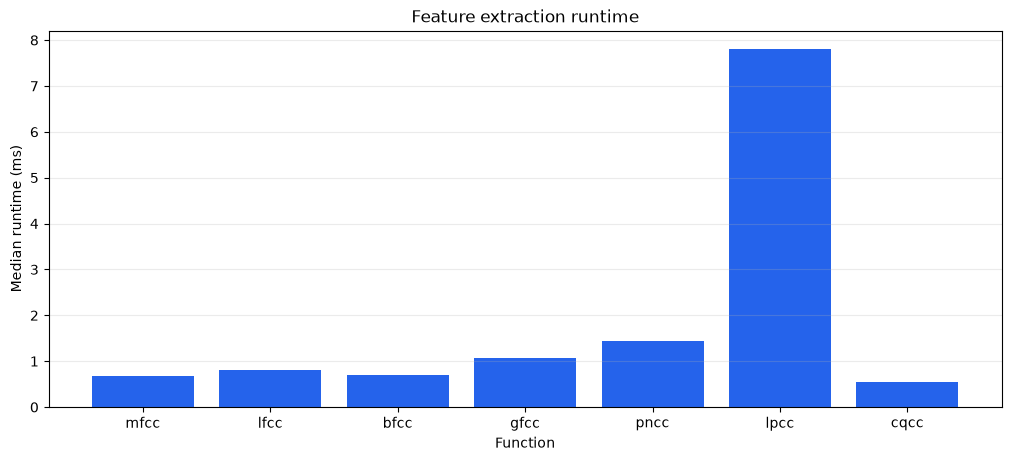

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
labels = [row["label"] for row in feature_rows]
values = [row["median_ms"] for row in feature_rows]
ax.bar(labels, values, color="#2563eb")
ax.set_title("Feature extraction runtime")
ax.set_xlabel("Function")
ax.set_ylabel("Median runtime (ms)")
ax.grid(True, axis="y", alpha=0.25)
plt.show()

## Scaling with Signal Duration

This section benchmarks MFCC extraction on increasing signal lengths. Runtime should grow roughly with the number of frames.

In [5]:
duration_rows = []
for seconds in [0.25, 0.5, 1.0, 2.0, 4.0]:
    sig = sine_wave(seconds, fs=fs)
    local_opts = spafe.FeatureOptions(fs=fs, nfft=256, nfilts=24, num_ceps=13, win_hop=0.02)
    row = benchmark(f"{seconds:.2f}s", lambda sig=sig, local_opts=local_opts: spafe.mfcc(sig, local_opts), repeats=3)
    row["seconds"] = seconds
    row["samples"] = len(sig)
    duration_rows.append(row)
print_table(duration_rows)

case                             min ms  median ms     max ms
--------------------------------------------------------------
0.25s                             0.093      0.094      0.097
0.50s                             0.155      0.156      0.159
1.00s                             0.301      0.302      0.320
2.00s                             1.407      1.542      1.719
4.00s                             1.023      1.026      1.061


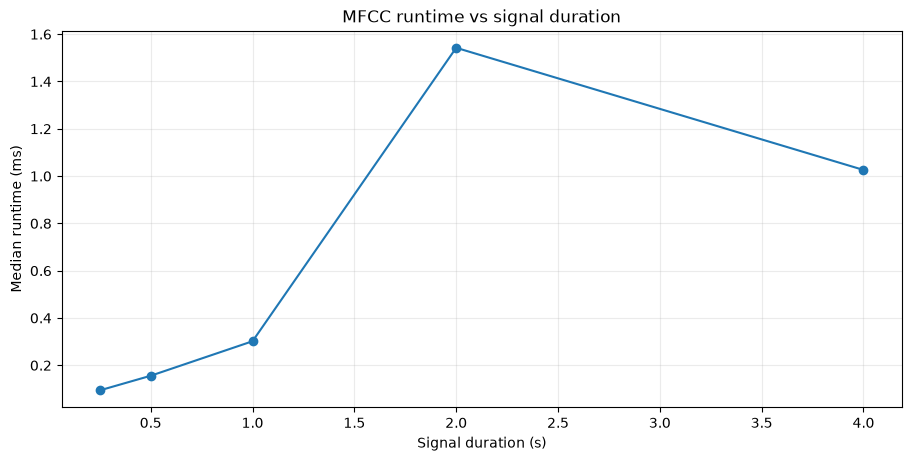

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
ax.plot(
    [row["seconds"] for row in duration_rows],
    [row["median_ms"] for row in duration_rows],
    marker="o",
)
ax.set_title("MFCC runtime vs signal duration")
ax.set_xlabel("Signal duration (s)")
ax.set_ylabel("Median runtime (ms)")
ax.grid(True, alpha=0.25)
plt.show()

## Hot Building Blocks

These timings isolate common operations: filter-bank construction, spectrogram extraction, pitch tracking, and cochleagram generation.

In [7]:
short_signal = sine_wave(0.5, fs=fs)
filter_opts = spafe.FilterBankOptions(nfilts=32, nfft=512, fs=fs, high_freq=8_000.0)
spec_opts = spafe.FeatureOptions(fs=fs, nfft=512, nfilts=32, win_hop=0.01)
coch_opts = spafe.CochleagramOptions(
    signal_size=4096,
    sr=fs,
    env_sr=400,
    filter_n=16,
    low_lim=50.0,
    high_lim=6000.0,
    sample_factor=2,
    downsampling_window_size=129,
    compression="power",
)

block_cases = [
    ("mel_filter_banks", lambda: spafe.mel_filter_banks(filter_opts)),
    ("gammatone_filter_banks", lambda: spafe.gammatone_filter_banks(filter_opts)),
    ("mel_spectrogram", lambda: spafe.mel_spectrogram(short_signal, spec_opts)),
    ("compute_yin", lambda: spafe.compute_yin(short_signal, fs=fs)),
    ("dominant_frequencies", lambda: spafe.get_dominant_frequencies(short_signal, fs=fs)),
    ("cochleagram", lambda: spafe.cochleagram(short_signal[:4096], coch_opts)),
]
block_rows = [benchmark(label, func, repeats=3) for label, func in block_cases]
print_table(block_rows)

case                             min ms  median ms     max ms
--------------------------------------------------------------
mel_filter_banks                  0.358      0.431      0.466
gammatone_filter_banks            1.179      1.314      1.534
mel_spectrogram                   0.537      0.538      0.543
compute_yin                       4.700      5.241      5.623
dominant_frequencies              0.330      0.349      0.415
cochleagram                       3.733      3.748      4.358


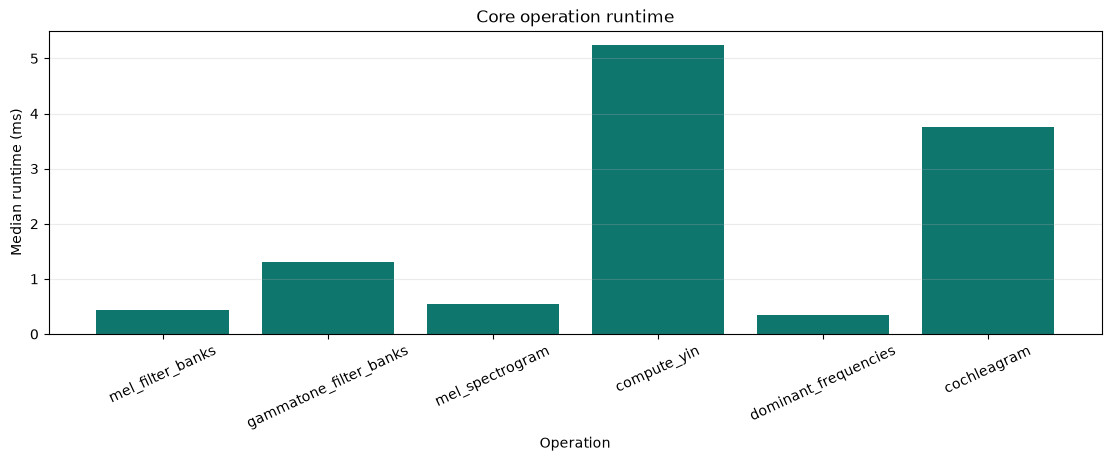

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
labels = [row["label"] for row in block_rows]
values = [row["median_ms"] for row in block_rows]
ax.bar(labels, values, color="#0f766e")
ax.set_title("Core operation runtime")
ax.set_xlabel("Operation")
ax.set_ylabel("Median runtime (ms)")
ax.tick_params(axis="x", rotation=25)
ax.grid(True, axis="y", alpha=0.25)
plt.show()

## Reading the Results

- Absolute timings depend on CPU, Python version, Rust optimization level, and whether the extension was built in debug or release mode.
- `maturin develop --release` is the most relevant local benchmark mode for real use.
- The first call can include FFT planner setup and cache effects, so the helper warms each case before measuring.
- To compare portable SIMD, install one environment with the default build and another with `portable-simd`, then rerun this same notebook and compare the tables.